In [12]:
import torch
from diffusion.training.classifier_trainer import ClassifierTrainer
from diffusion.training.encoder_trainer import EncoderTrainer
from whar_datasets.support.getter import WHARDatasetID, get_dataset_cfg
from diffusion.sampleables.whar_sampleable import WHARSampleable, TrainValTest
from diffusion.architectures.classifiers.wisdm_classifier import WISDMClassifier

In [13]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [14]:
cfg = get_dataset_cfg(WHARDatasetID.UCI_HAR)
scv_group_index = 0

2025-12-21 11:36:30,807 - whar-datasets - INFO - Running DownloadingStep
2025-12-21 11:36:30,808 - whar-datasets - INFO - Checking hash for DownloadingStep
2025-12-21 11:36:30,809 - whar-datasets - INFO - Hash is up to date
2025-12-21 11:36:30,809 - whar-datasets - INFO - Running ParsingStep
2025-12-21 11:36:30,810 - whar-datasets - INFO - Checking hash for ParsingStep
2025-12-21 11:36:30,811 - whar-datasets - INFO - Hash is up to date
2025-12-21 11:36:30,812 - whar-datasets - INFO - Running WindowingStep
2025-12-21 11:36:30,812 - whar-datasets - INFO - Checking hash for WindowingStep
2025-12-21 11:36:30,814 - whar-datasets - INFO - Hash is up to date
2025-12-21 11:36:30,814 - whar-datasets - INFO - Loading windowing
2025-12-21 11:36:30,826 - whar-datasets - INFO - activity_ids from 0 to 5
2025-12-21 11:36:30,829 - whar-datasets - INFO - subject_ids from 0 to 29
2025-12-21 11:36:30,844 - whar-datasets - INFO - train: 8002 | test: 1497
2025-12-21 11:36:30,857 - whar-datasets - INFO - Ru

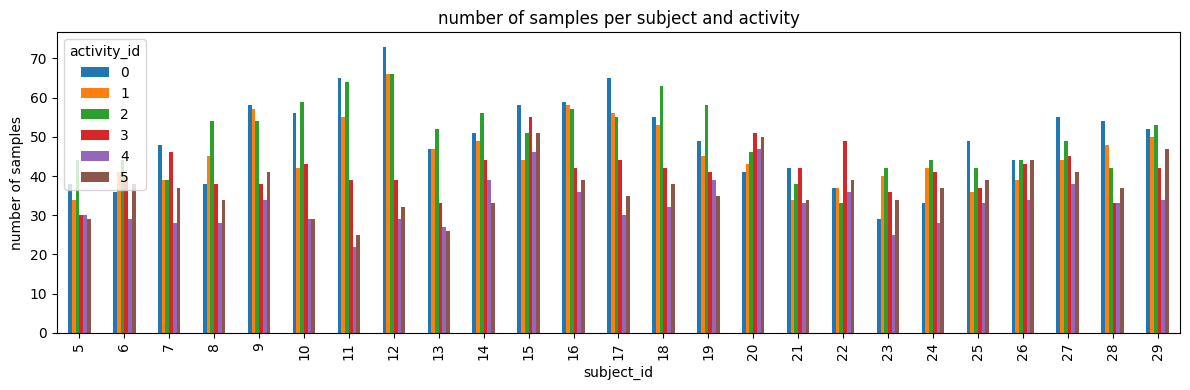

2025-12-21 11:36:33,285 - whar-datasets - INFO - Running DownloadingStep
2025-12-21 11:36:33,285 - whar-datasets - INFO - Checking hash for DownloadingStep
2025-12-21 11:36:33,286 - whar-datasets - INFO - Hash is up to date
2025-12-21 11:36:33,286 - whar-datasets - INFO - Running ParsingStep
2025-12-21 11:36:33,286 - whar-datasets - INFO - Checking hash for ParsingStep
2025-12-21 11:36:33,287 - whar-datasets - INFO - Hash is up to date
2025-12-21 11:36:33,287 - whar-datasets - INFO - Running WindowingStep
2025-12-21 11:36:33,287 - whar-datasets - INFO - Checking hash for WindowingStep
2025-12-21 11:36:33,289 - whar-datasets - INFO - Hash is up to date
2025-12-21 11:36:33,289 - whar-datasets - INFO - Loading windowing
2025-12-21 11:36:33,294 - whar-datasets - INFO - activity_ids from 0 to 5
2025-12-21 11:36:33,295 - whar-datasets - INFO - subject_ids from 0 to 29
2025-12-21 11:36:33,298 - whar-datasets - INFO - train: 8002 | test: 1497
2025-12-21 11:36:33,298 - whar-datasets - INFO - Ru

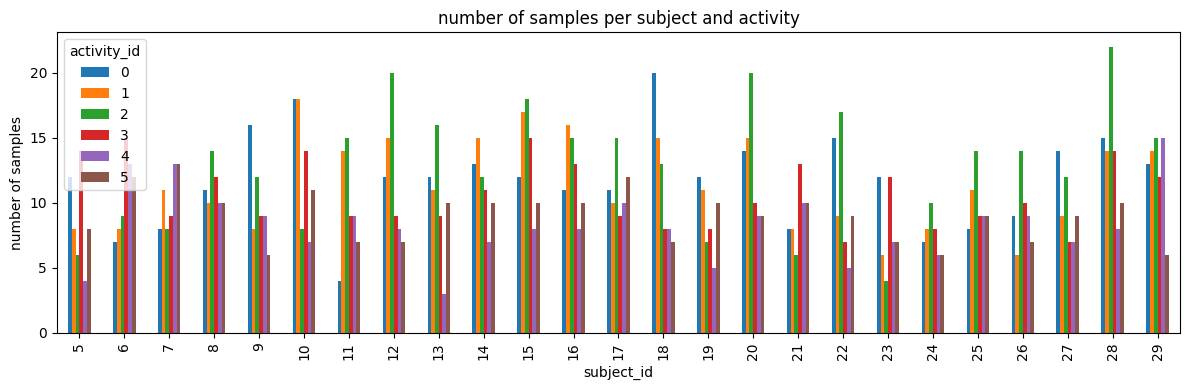

(128, 9)
(18, 33, 43)
6


In [15]:
sampeable = WHARSampleable(
    cfg=cfg,
    scv_group_index=scv_group_index,
    fold=TrainValTest.TRAIN,
)

val_sampeable = WHARSampleable(
    cfg=cfg,
    scv_group_index=scv_group_index,
    fold=TrainValTest.VAL,
)

print(sampeable.signal_shape)
print(sampeable.shape)
print(sampeable.num_classes)

In [18]:
classifier = WISDMClassifier(
    in_c=sampeable.shape[0], num_classes=sampeable.num_classes, size=5120
).to(device)

trainer = ClassifierTrainer(
    classifier=classifier,
    train_data=sampeable,
    val_data=val_sampeable,
    num_classes=sampeable.num_classes,
)

# trainer = EncoderTrainer(
#     encoder=classifier,
#     train_data=sampeable,
#     val_data=val_sampeable,
#     num_classes=sampeable.num_classes,
# )

2025-12-21 11:36:49,931 - flow-matching - INFO - Training model with size: 2.594 MiB
Epoch 0/15: 100%|██████████| 500/500 [00:31<00:00, 16.01it/s, train_loss=0.445856]


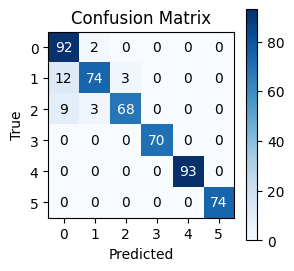

2025-12-21 11:37:21,892 - flow-matching - INFO - val loss: 0.9419999718666077, best val loss: 0.9419999718666077
Epoch 1/15: 100%|██████████| 500/500 [00:31<00:00, 15.98it/s, train_loss=0.128057]


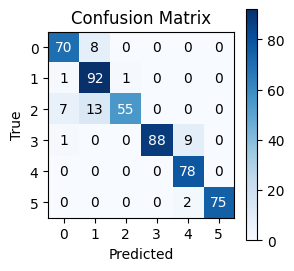

2025-12-21 11:37:53,904 - flow-matching - INFO - val loss: 0.9160000085830688, best val loss: 0.9419999718666077
Epoch 2/15: 100%|██████████| 500/500 [00:30<00:00, 16.23it/s, train_loss=0.076573]


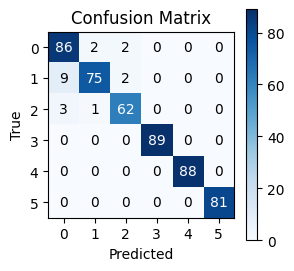

2025-12-21 11:38:25,449 - flow-matching - INFO - val loss: 0.9620000123977661, best val loss: 0.9620000123977661
Epoch 3/15: 100%|██████████| 500/500 [00:31<00:00, 15.70it/s, train_loss=0.048497]


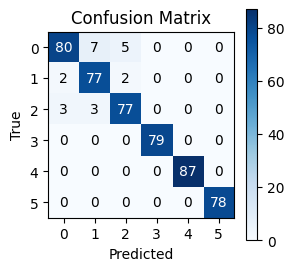

2025-12-21 11:38:58,042 - flow-matching - INFO - val loss: 0.9559999704360962, best val loss: 0.9620000123977661
Epoch 4/15:  27%|██▋       | 134/500 [00:08<00:23, 15.43it/s, train_loss=0.038029]


KeyboardInterrupt: 

In [19]:
state_dict = trainer.train(
    num_epochs=15,
    device=device,
    lr=3e-4,
    batch_size=64,
    steps_per_epoch=500,
    validate=True,
    patience=5,
    decreasing=False,
    val_batch_size=500,
)

In [20]:
torch.save(classifier.state_dict(), "./models/classifier_ucihar.pt")